<a href="https://colab.research.google.com/github/Aditipujari10/Deep_Learning_Lab/blob/main/DL_EXP_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [ ]:
baseline_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=128
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8937 - loss: 0.3696 - val_accuracy: 0.9495 - val_loss: 0.1808
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9548 - loss: 0.1544 - val_accuracy: 0.9558 - val_loss: 0.1454
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9684 - loss: 0.1087 - val_accuracy: 0.9678 - val_loss: 0.1096
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9754 - loss: 0.0833 - val_accuracy: 0.9697 - val_loss: 0.1032
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9806 - loss: 0.0647 - val_accuracy: 0.9709 - val_loss: 0.0946
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0522 - val_accuracy: 0.9720 - val_loss: 0.0928
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9886 - loss: 0.0393 - val_accuracy: 0.9741 - val_loss: 0.0907
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9905 - loss: 0.0331 - val_accuracy: 0.

In [ ]:
dropout_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=128
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7325 - loss: 0.8357 - val_accuracy: 0.9299 - val_loss: 0.2448
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8840 - loss: 0.4066 - val_accuracy: 0.9439 - val_loss: 0.1914
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9074 - loss: 0.3249 - val_accuracy: 0.9538 - val_loss: 0.1644
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9212 - loss: 0.2807 - val_accuracy: 0.9593 - val_loss: 0.1459
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9288 - loss: 0.2564 - val_accuracy: 0.9618 - val_loss: 0.1369
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9329 - loss: 0.2380 - val_accuracy: 0.9642 - val_loss: 0.1275
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9384 - loss: 0.2194 - val_accuracy: 0.9685 - val_loss: 0.1190
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9419 - loss: 0.2096 - val_accuracy: 0.

In [ ]:
l2_model = models.Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=128
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8928 - loss: 0.5848 - val_accuracy: 0.9454 - val_loss: 0.3615
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9509 - loss: 0.3266 - val_accuracy: 0.9592 - val_loss: 0.2902
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9608 - loss: 0.2713 - val_accuracy: 0.9644 - val_loss: 0.2571
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9685 - loss: 0.2377 - val_accuracy: 0.9678 - val_loss: 0.2306
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9700 - loss: 0.2183 - val_accuracy: 0.9682 - val_loss: 0.2179
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9730 - loss: 0.2017 - val_accuracy: 0.9684 - val_loss: 0.2150
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9753 - loss: 0.1885 - val_accuracy: 0.9717 - val_loss: 0.1981
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9755 - loss: 0.1821 - val_accuracy: 0.

In [ ]:
bn_model = models.Sequential([
    layers.Dense(128, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=128
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9132 - loss: 0.3236 - val_accuracy: 0.9565 - val_loss: 0.1555
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9678 - loss: 0.1148 - val_accuracy: 0.9664 - val_loss: 0.1109
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.0745 - val_accuracy: 0.9728 - val_loss: 0.0902
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9843 - loss: 0.0535 - val_accuracy: 0.9721 - val_loss: 0.0940
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0392 - val_accuracy: 0.9755 - val_loss: 0.0838
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9911 - loss: 0.0309 - val_accuracy: 0.9743 - val_loss: 0.0857
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0259 - val_accuracy: 0.9743 - val_loss: 0.0913
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9942 - loss: 0.0203 - val_accuracy: 0.

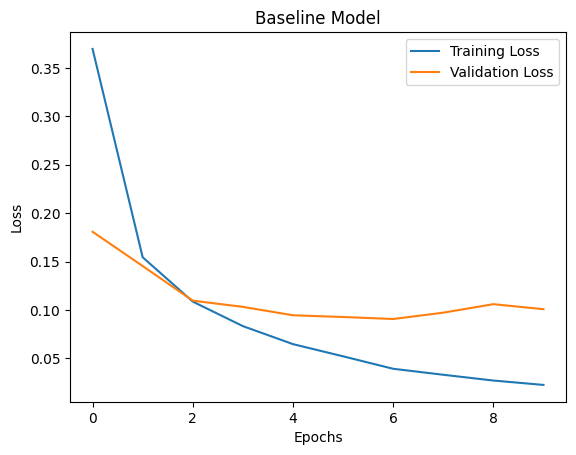

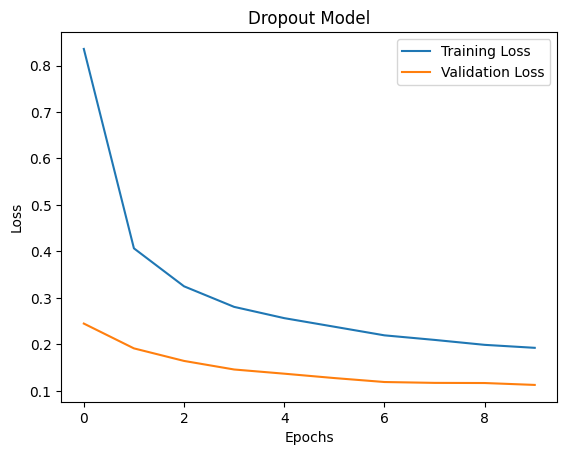

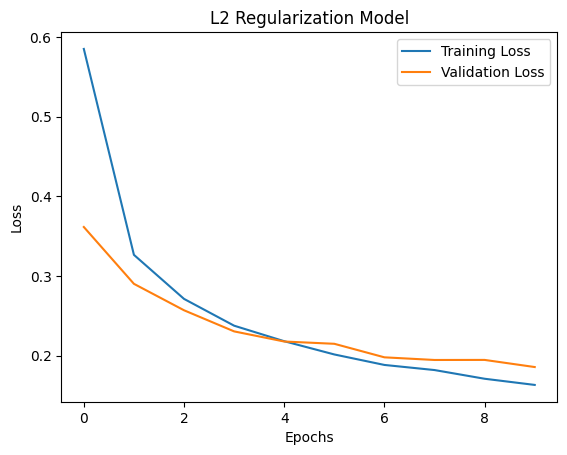

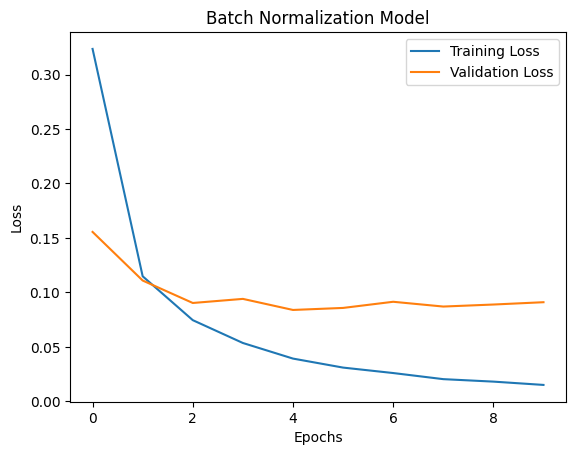

Baseline Test Accuracy: 0.9753
Dropout Test Accuracy: 0.9685
L2 Regularization Test Accuracy: 0.9703
Batch Normalization Test Accuracy: 0.9780


In [ ]:
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()



plot_loss(history_baseline, "Baseline Model")
plot_loss(history_dropout, "Dropout Model")
plot_loss(history_l2, "L2 Regularization Model")
plot_loss(history_bn, "Batch Normalization Model")


models_list = {
    "Baseline": baseline_model,
    "Dropout": dropout_model,
    "L2 Regularization": l2_model,
    "Batch Normalization": bn_model
}

for name, model in models_list.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")
